#**Project Overview**

In large and diverse classrooms, especially in the Indian education system, students exhibit varied learning styles and responses. A one-size-fits-all teaching method often fails to engage all learners effectively. Teachers attempt to adapt—switching between lectures, visual aids, and discussions—but lack data-driven feedback to know which teaching style helps which students or student groups.






Objective

This project aims to build a predictive machine learning model that:

Identifies which students are likely to benefit from specific teaching styles.

Enables educators to customize teaching approaches to boost learning outcomes.

Helps in batch-level optimization of teaching methods when personalization at the individual level is impractical.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv("/content/UNI_DATASET.csv")

In [3]:
df = df1.copy()

In [4]:
df.head()

,Age,Gender,Parental_Education,Family_Income,Previous_Grades,Attendance,Class_Participation,Study_Hours,Major,School_Type,...,Educational_Tech_Use,Peer_Group,Bullying,Study_Space,Tutoring,Mentoring,Lack_of_Interest,Time_Wasted_on_Social_Media,Sports_Participation,Learning_Style
0,20.8,Male,High School,60000,B,96.3,High,0.8,Business,Public,...,Yes,Positive,No,No,Yes,Yes,Medium,2.0,High,Auditory
1,18.3,Female,High School,60000,B,73.9,High,3.5,Law,Private,...,No,Positive,Yes,No,NaN,Yes,High,4.0,High,Auditory
2,18.9,Female,Graduate,30000,A,79.2,High,6.8,Engineering,Public,...,Yes,Positive,Yes,Yes,Yes,Yes,Medium,2.3,NaN,Auditory
3,24.8,Female,Graduate,50000,B,64.5,Medium,NaN,Law,Public,...,Yes,Neutral,No,Yes,No,No,Low,4.6,High,Visual
4,21.4,Female,NaN,50000,B,64.2,Low,3.9,Science,Public,...,No,Neutral,No,Yes,No,Yes,High,1.2,High,Kinesthetic


In [5]:
df.describe()

,Age,Attendance,Study_Hours,Class_Size,Sleep_Patterns,Screen_Time,Time_Wasted_on_Social_Media
count,2858.000000,2791.000000,2797.000000,2857.000000,2643.000000,2849.000000,2827.000000
mean,19.897236,78.879226,4.828956,29.973014,6.147631,4.131611,2.487336
std,2.480463,11.282991,2.425893,5.813964,1.390491,2.694632,1.446604
min,11.500000,59.600000,-0.300000,19.700000,3.600000,-0.400000,-0.600000
25%,18.200000,68.985000,2.600000,25.000000,4.900000,1.400000,1.300000
50%,19.900000,78.500000,5.600000,30.000000,6.300000,4.900000,2.500000
75%,21.600000,88.400000,6.900000,35.100000,7.300000,6.500000,3.700000
max,30.600000,100.300000,8.400000,40.400000,9.400000,9.930000,5.400000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2994 entries, 0 to 2993
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          2858 non-null   float64
 1   Gender                       2865 non-null   object 
 2   Parental_Education           2865 non-null   object 
 3   Family_Income                2858 non-null   object 
 4   Previous_Grades              2850 non-null   object 
 5   Attendance                   2791 non-null   float64
 6   Class_Participation          2877 non-null   object 
 7   Study_Hours                  2797 non-null   float64
 8   Major                        2817 non-null   object 
 9   School_Type                  2833 non-null   object 
 10  Financial_Status             2795 non-null   object 
 11  Parental_Involvement         2839 non-null   object 
 12  Educational_Resources        2829 non-null   object 
 13  Motivation        

In [7]:
df.shape

(2994, 34)

In [8]:
df.columns

Index(['Age', 'Gender', 'Parental_Education', 'Family_Income',
       'Previous_Grades', 'Attendance', 'Class_Participation', 'Study_Hours',
       'Major', 'School_Type', 'Financial_Status', 'Parental_Involvement',
       'Educational_Resources', 'Motivation', 'Self_Esteem', 'Stress_Levels',
       'School_Environment', 'Professor_Quality', 'Class_Size',
       'Extracurricular_Activities', 'Sleep_Patterns', 'Nutrition',
       'Physical_Activity', 'Screen_Time', 'Educational_Tech_Use',
       'Peer_Group', 'Bullying', 'Study_Space', 'Tutoring', 'Mentoring',
       'Lack_of_Interest', 'Time_Wasted_on_Social_Media',
       'Sports_Participation', 'Learning_Style'],
      dtype='object')

In [9]:
df.columns=df.columns.str.strip()

**Checking Null Target Values**

In [10]:
df['Learning_Style'].isnull().sum()

np.int64(0)

## **Handling Missing Values**


In [11]:
#Checking missing values
df.isnull().sum()

,0
Age,136
Gender,129
Parental_Education,129
Family_Income,136
Previous_Grades,144
Attendance,203
Class_Participation,117
Study_Hours,197
Major,177
School_Type,161


**1. Dealing with numerical columns**

In [12]:
df.select_dtypes(np.number).describe()

,Age,Attendance,Study_Hours,Class_Size,Sleep_Patterns,Screen_Time,Time_Wasted_on_Social_Media
count,2858.000000,2791.000000,2797.000000,2857.000000,2643.000000,2849.000000,2827.000000
mean,19.897236,78.879226,4.828956,29.973014,6.147631,4.131611,2.487336
std,2.480463,11.282991,2.425893,5.813964,1.390491,2.694632,1.446604
min,11.500000,59.600000,-0.300000,19.700000,3.600000,-0.400000,-0.600000
25%,18.200000,68.985000,2.600000,25.000000,4.900000,1.400000,1.300000
50%,19.900000,78.500000,5.600000,30.000000,6.300000,4.900000,2.500000
75%,21.600000,88.400000,6.900000,35.100000,7.300000,6.500000,3.700000
max,30.600000,100.300000,8.400000,40.400000,9.400000,9.930000,5.400000


In [14]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].skew()

,0
Age,0.024332
Attendance,0.112499
Study_Hours,-0.475008
Class_Size,0.005617
Sleep_Patterns,0.078562
Screen_Time,-0.059130
Time_Wasted_on_Social_Media,0.006080


In [15]:
# Impute mean for normally distributed columns
mean_cols = ['Age', 'Attendance', 'Class_Size', 'Sleep_Patterns', 'Screen_Time', 'Time_Wasted_on_Social_Media']
for col in mean_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute median for skewed column(s)
median_cols = ['Study_Hours']
for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)


**2.Dealing with categorical columns**

In [16]:
cc = df.select_dtypes(exclude=[np.number])
catgeorical_columns = cc.columns
catgeorical_columns


Index(['Gender', 'Parental_Education', 'Family_Income', 'Previous_Grades',
       'Class_Participation', 'Major', 'School_Type', 'Financial_Status',
       'Parental_Involvement', 'Educational_Resources', 'Motivation',
       'Self_Esteem', 'Stress_Levels', 'School_Environment',
       'Professor_Quality', 'Extracurricular_Activities', 'Nutrition',
       'Physical_Activity', 'Educational_Tech_Use', 'Peer_Group', 'Bullying',
       'Study_Space', 'Tutoring', 'Mentoring', 'Lack_of_Interest',
       'Sports_Participation', 'Learning_Style'],
      dtype='object')

In [ ]:
# Define ordinal mappings
ordinal_mappings = {
    'Class_Participation': {'Low': 1, 'Medium': 2, 'High': 3},
    'Financial_Status': {'Low': 1, 'Medium': 2, 'High': 3},
    'Parental_Involvement': {'Low': 1, 'Medium': 2, 'High': 3},
    'Motivation': {'Low': 1, 'Medium': 2, 'High': 3},
    'Self_Esteem': {'Low': 1, 'Medium': 2, 'High': 3},
    'Stress_Levels': {'Low': 1, 'Medium': 2, 'High': 3},
    'School_Environment': {'Negative': 1, 'Neutral': 2, 'Positive': 3},
    'Professor_Quality': {'Low': 1, 'Medium': 2, 'High': 3},
    'Physical_Activity': {'Low': 1, 'Medium': 2, 'High': 3},
    'Lack_of_Interest': {'Low': 1, 'Medium': 2, 'High': 3},
    'Sports_Participation': {'Low': 1, 'Medium': 2, 'High': 3},
    'Previous_Grades': {'C': 1, 'B': 2, 'A': 3},
    'Grades': {'C': 1, 'B': 2, 'A': 3}
}

# Get list of all categorical columns (if not already defined)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Apply ordinal median imputation
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        temp_col = col + '_num'
        df[temp_col] = df[col].map(mapping)
        median_val = df[temp_col].median()
        df[temp_col].fillna(median_val, inplace=True)
        reverse_map = {v: k for k, v in mapping.items()}
        df[col] = df[temp_col].round().astype(int).map(reverse_map)
        df.drop(columns=[temp_col], inplace=True)

# Remaining nominal columns 
ordinal_cols = list(ordinal_mappings.keys())
nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

# Apply nominal mode imputation
for col in nominal_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

In [18]:
df.isnull().sum()

,0
Age,0
Gender,0
Parental_Education,0
Family_Income,0
Previous_Grades,0
Attendance,0
Class_Participation,0
Study_Hours,0
Major,0
School_Type,0


# **EDA**

**Distribution of target variable**

<Axes: xlabel='Learning_Style', ylabel='count'>

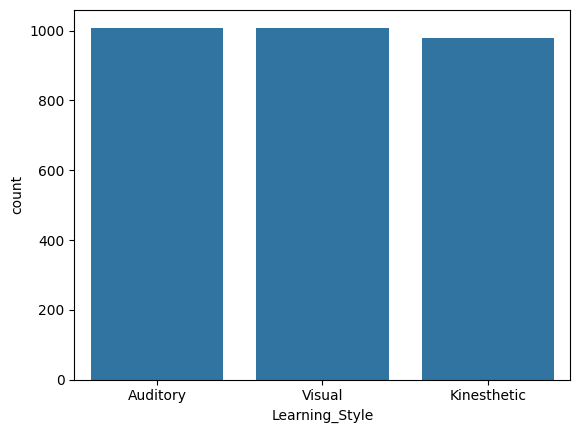

In [ ]:
#Target distribution
df['Learning_Style'].value_counts()
sns.countplot(x='Learning_Style', data=df)

Univariate Analysis of Numerical Variables



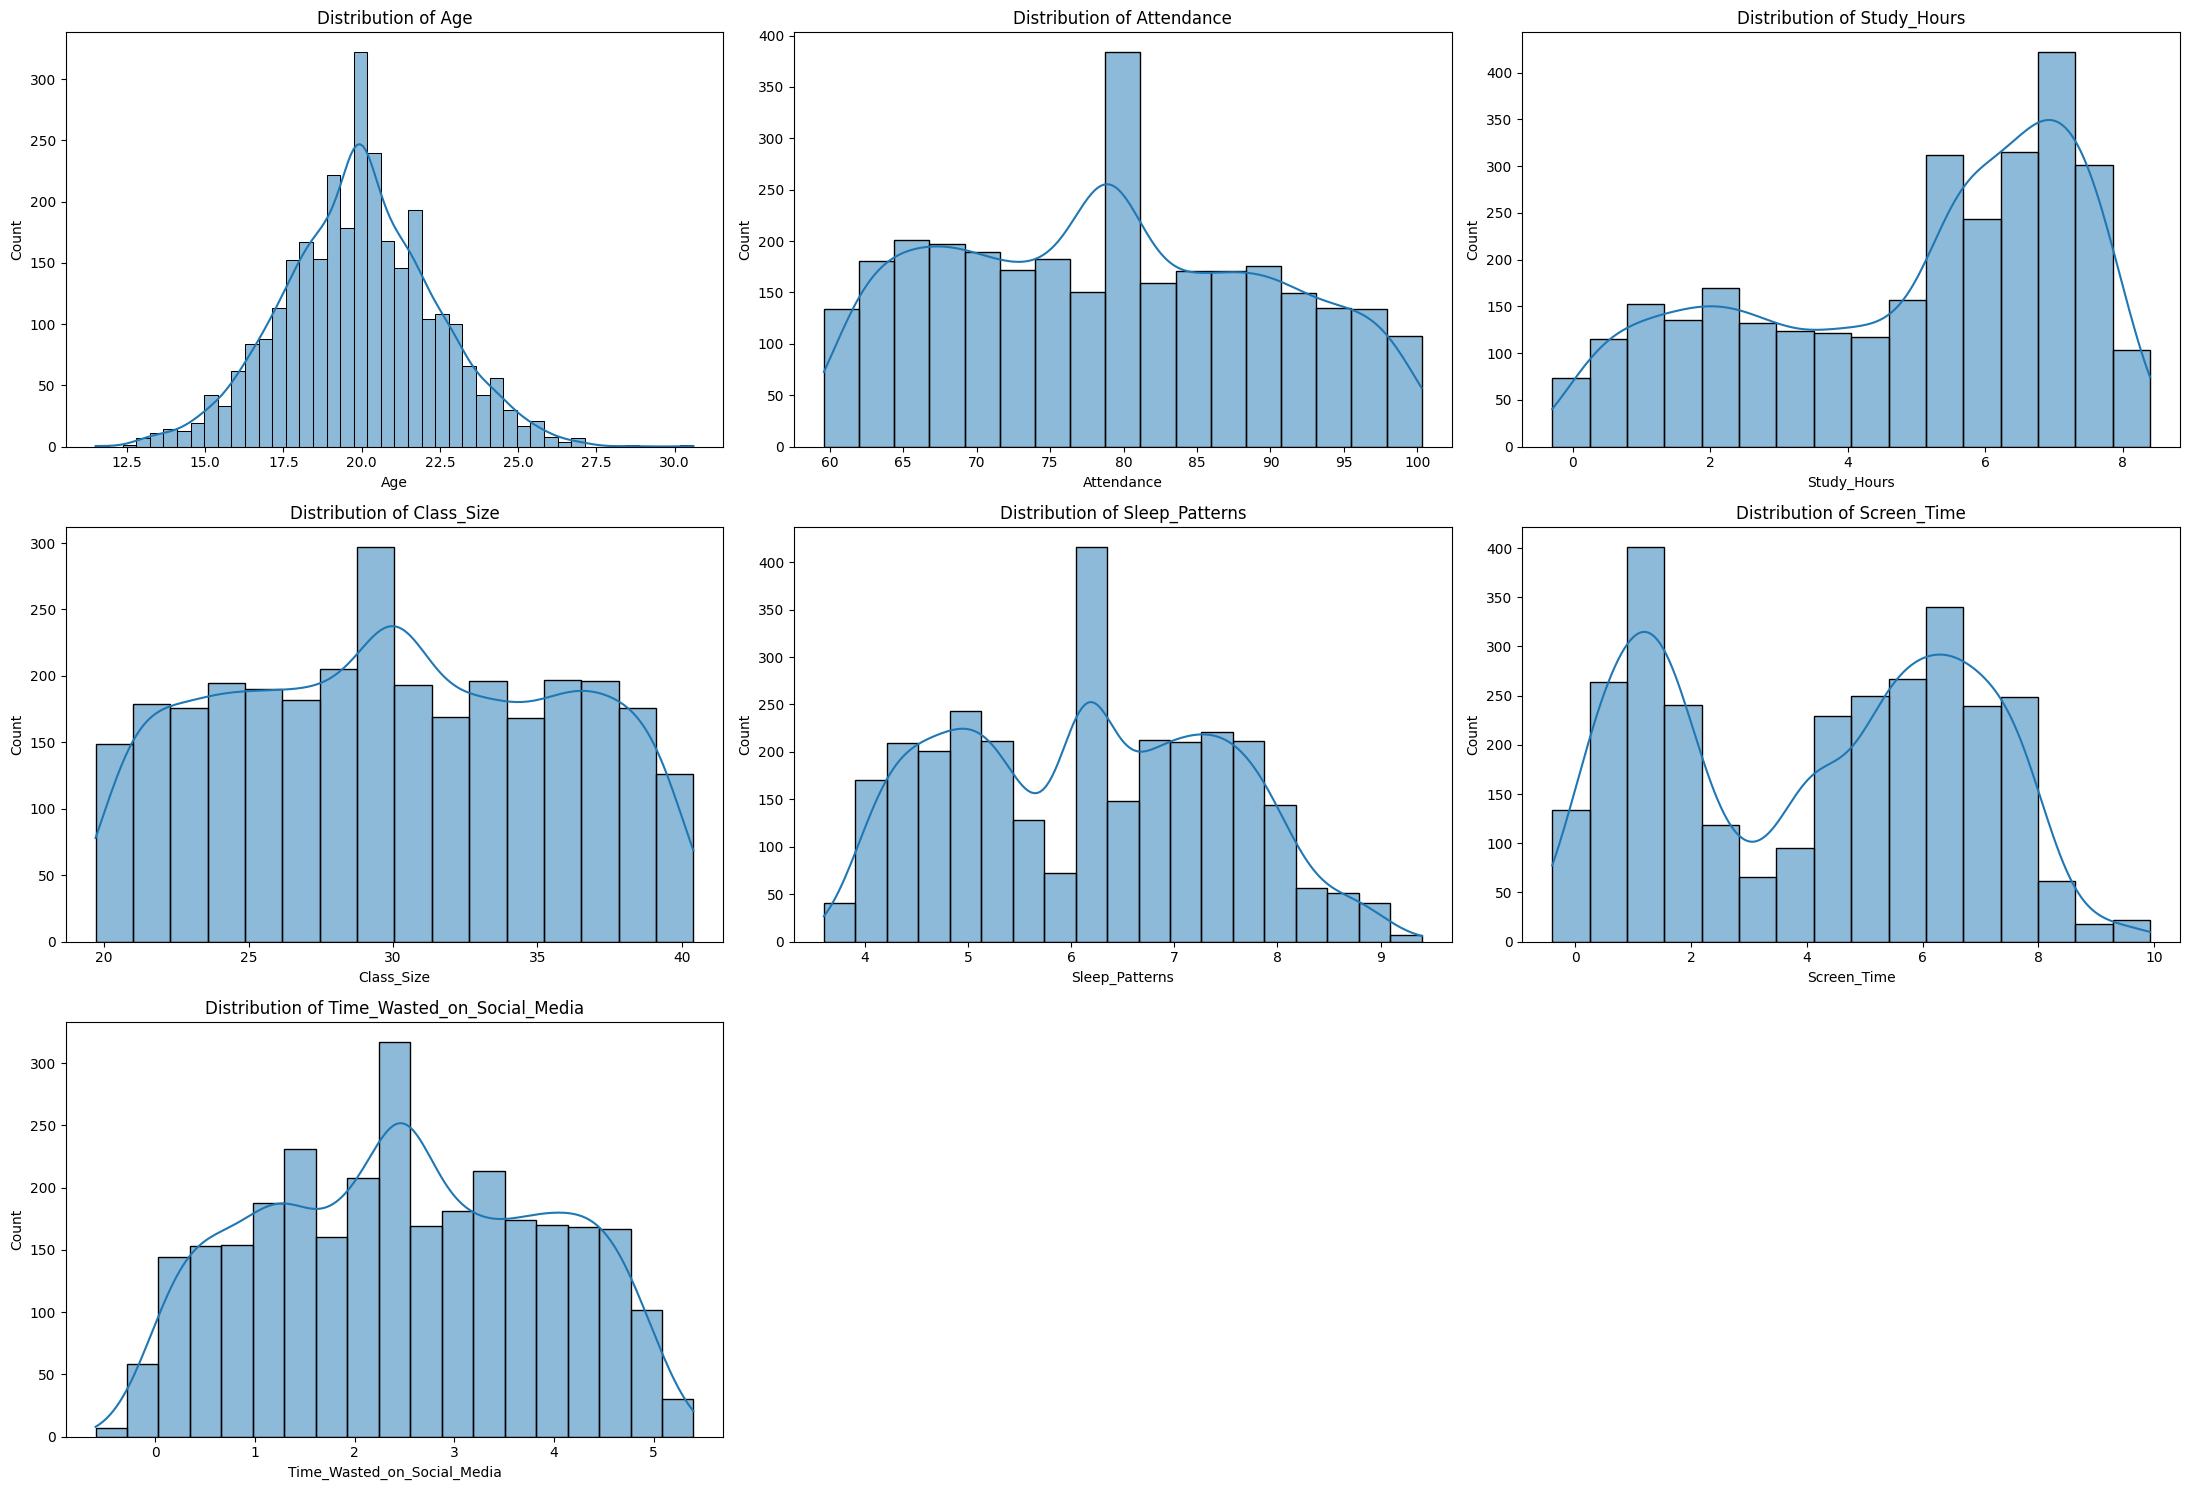

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # automatic rows based on features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
#as observed there are null values in Time wasted on social media which makes no semantic or statistical sense
print("Negative Time_Wasted_on_Social_Media count:", (df['Time_Wasted_on_Social_Media'] < 0).sum())
print(df[df['Time_Wasted_on_Social_Media'] < 0]['Time_Wasted_on_Social_Media'].describe())

Negative Time_Wasted_on_Social_Media count: 30
count    30.000000
mean     -0.183333
std       0.117688
min      -0.600000
25%      -0.200000
50%      -0.100000
75%      -0.100000
max      -0.100000
Name: Time_Wasted_on_Social_Media, dtype: float64


In [22]:
print("Negative Study_Hours count:", (df['Study_Hours'] < 0).sum())
print(df[df['Study_Hours'] < 0]['Study_Hours'].describe())

Negative Study_Hours count: 18
count    18.000000
mean     -0.150000
std       0.070711
min      -0.300000
25%      -0.200000
50%      -0.100000
75%      -0.100000
max      -0.100000
Name: Study_Hours, dtype: float64


In [23]:
print("Negative Screen Time count:", (df['Screen_Time'] < 0).sum())
print(df[df['Screen_Time'] < 0]['Screen_Time'].describe())

Negative Screen Time count: 39
count    39.000000
mean     -0.194872
std       0.105003
min      -0.400000
25%      -0.300000
50%      -0.200000
75%      -0.100000
max      -0.100000
Name: Screen_Time, dtype: float64


In [24]:
df = df[
    (df['Study_Hours'] >= 0) &
    (df['Screen_Time'] >= 0) &
    (df['Time_Wasted_on_Social_Media'] >= 0)
]


Univariate Analysis of Categorical Variables

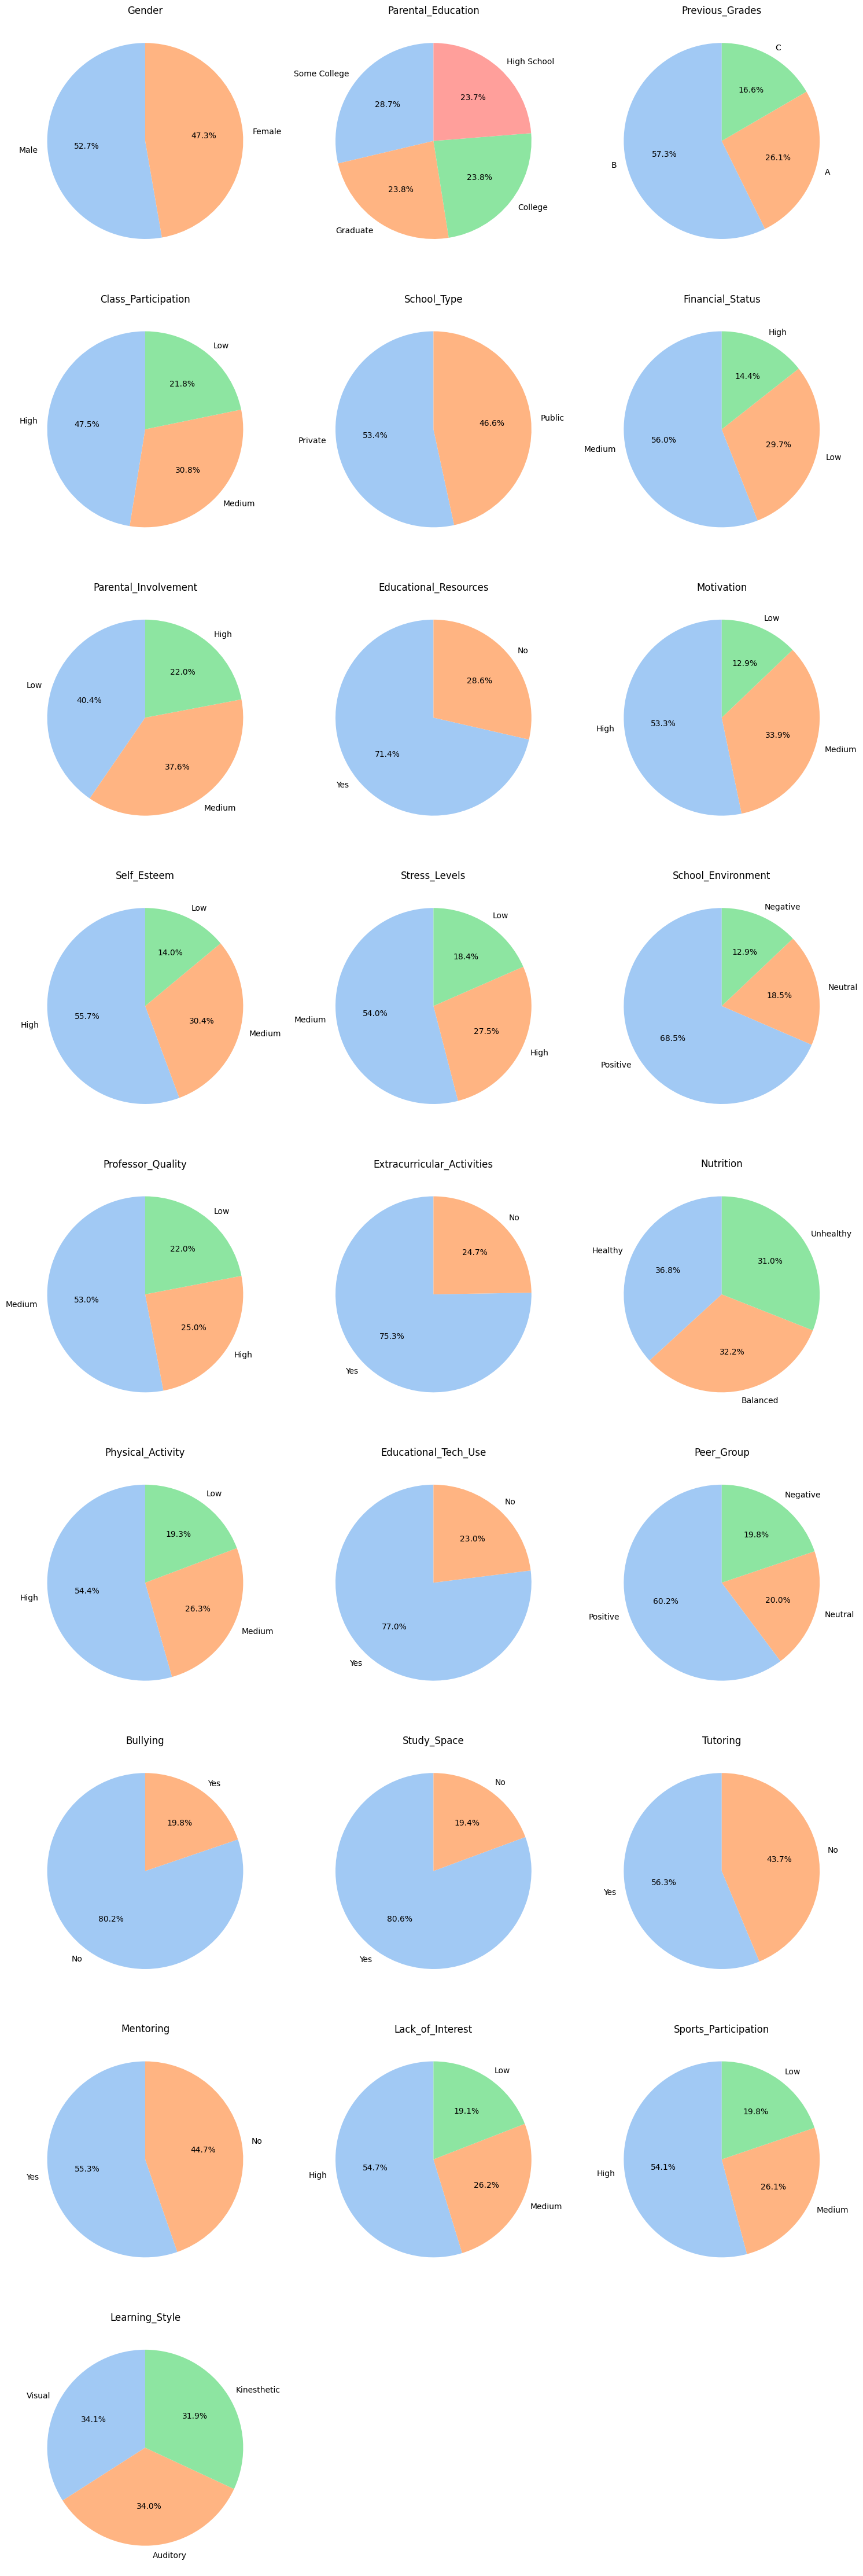

In [ ]:
# Filter categorical columns with ≤ 5 unique values 
few_cat_cols = [col for col in catgeorical_columns if df[col].nunique(dropna=False) <= 5]

# Setup subplot grid
n_cols = 3
n_rows = -(-len(few_cat_cols) // n_cols)  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Generate pie charts
for ax, col in zip(axes, few_cat_cols):
    counts = df[col].value_counts(dropna=False)
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
           colors=sns.color_palette("pastel"))
    ax.set_title(col)

# Hide unused axes
for ax in axes[len(few_cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()



**BIVARIATE ANALYSIS**

In [26]:
catgeorical_columns

Index(['Gender', 'Parental_Education', 'Family_Income', 'Previous_Grades',
       'Class_Participation', 'Major', 'School_Type', 'Financial_Status',
       'Parental_Involvement', 'Educational_Resources', 'Motivation',
       'Self_Esteem', 'Stress_Levels', 'School_Environment',
       'Professor_Quality', 'Extracurricular_Activities', 'Nutrition',
       'Physical_Activity', 'Educational_Tech_Use', 'Peer_Group', 'Bullying',
       'Study_Space', 'Tutoring', 'Mentoring', 'Lack_of_Interest',
       'Sports_Participation', 'Learning_Style'],
      dtype='object')

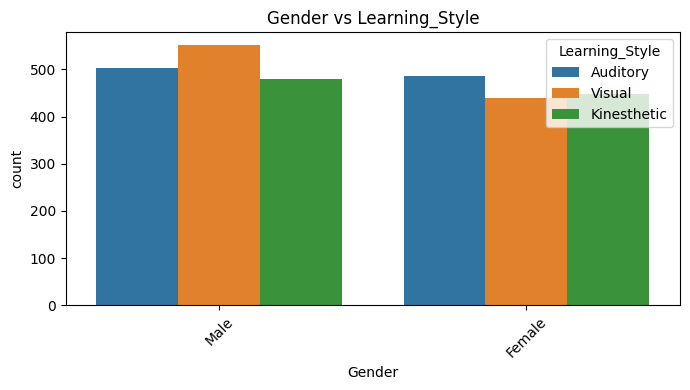

Chi-square test for Gender vs Learning_Style → p-value = 0.0699


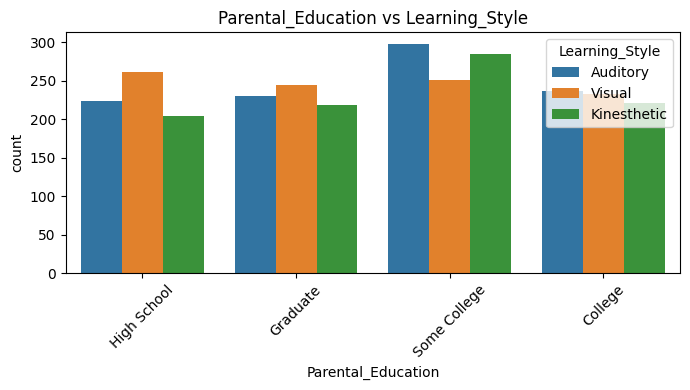

Chi-square test for Parental_Education vs Learning_Style → p-value = 0.0831


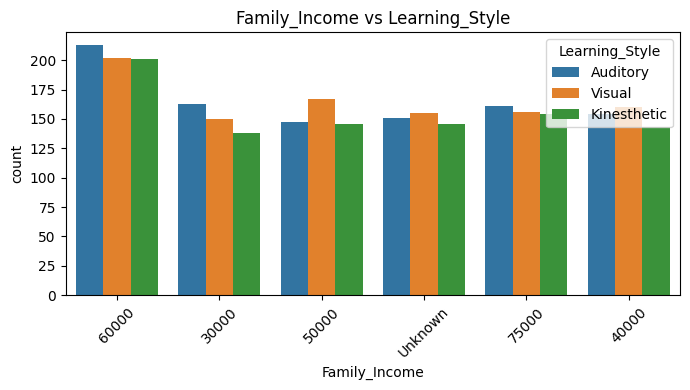

Chi-square test for Family_Income vs Learning_Style → p-value = 0.9785


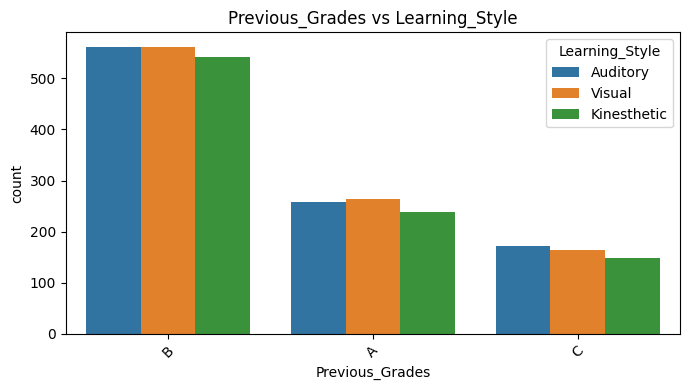

Chi-square test for Previous_Grades vs Learning_Style → p-value = 0.9060


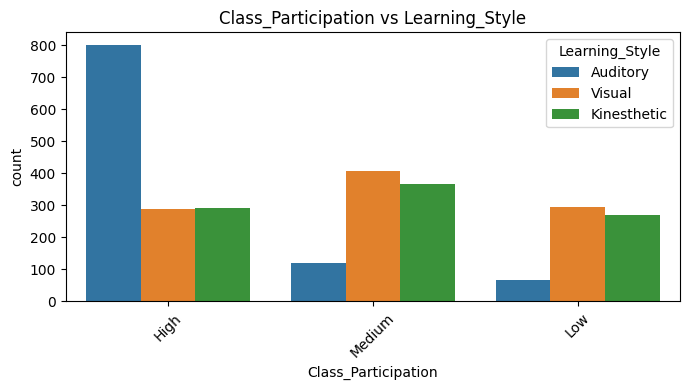

Chi-square test for Class_Participation vs Learning_Style → p-value = 0.0000


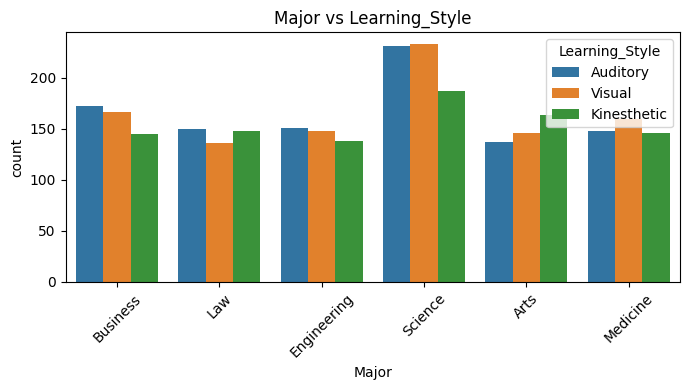

Chi-square test for Major vs Learning_Style → p-value = 0.3507


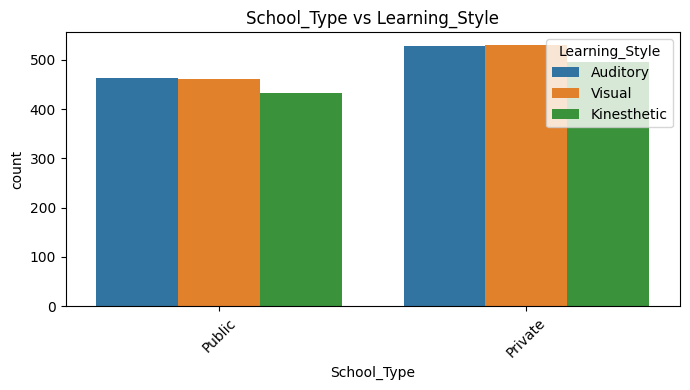

Chi-square test for School_Type vs Learning_Style → p-value = 0.9968


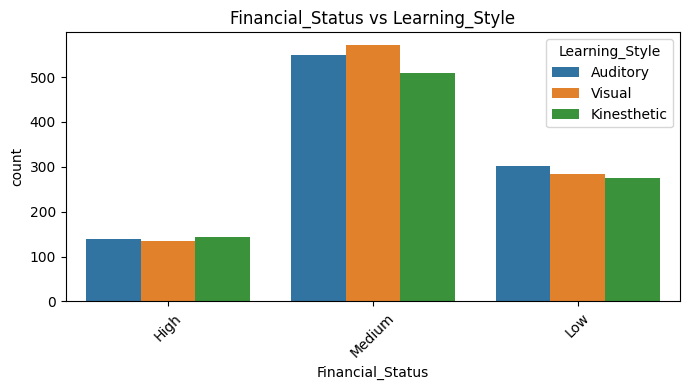

Chi-square test for Financial_Status vs Learning_Style → p-value = 0.6202


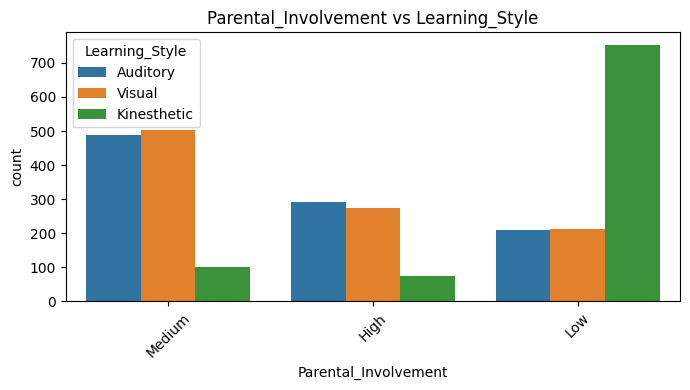

Chi-square test for Parental_Involvement vs Learning_Style → p-value = 0.0000


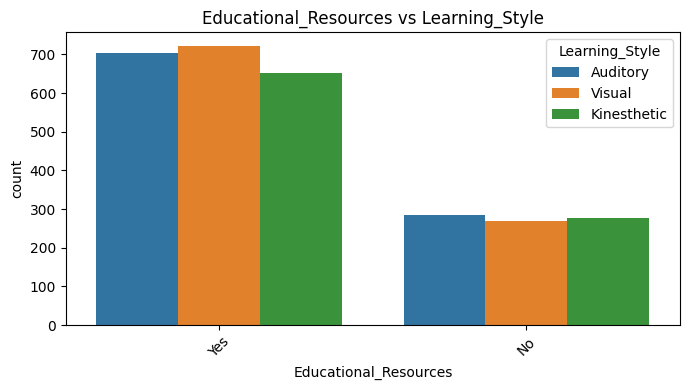

Chi-square test for Educational_Resources vs Learning_Style → p-value = 0.4229


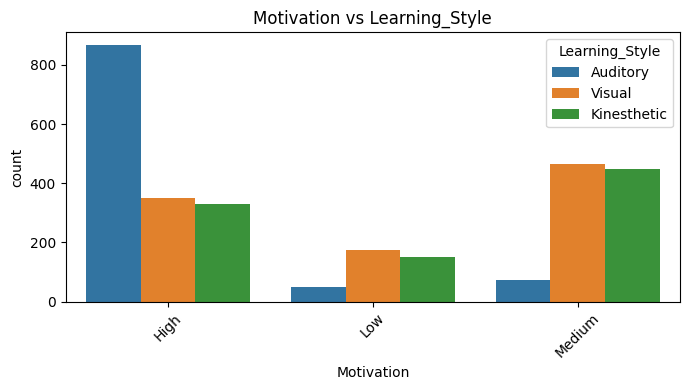

Chi-square test for Motivation vs Learning_Style → p-value = 0.0000


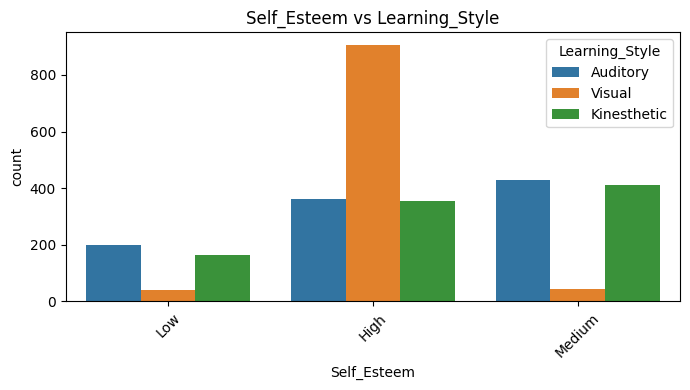

Chi-square test for Self_Esteem vs Learning_Style → p-value = 0.0000


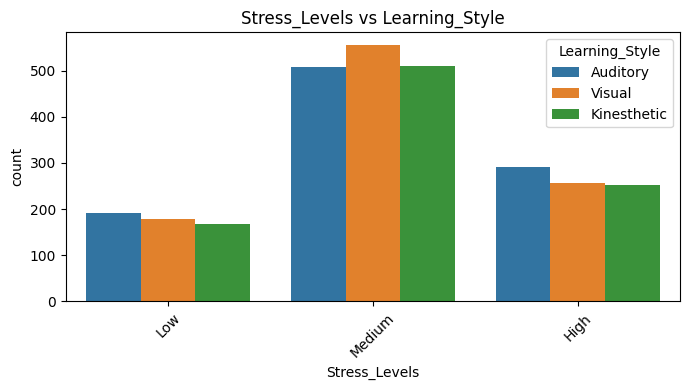

Chi-square test for Stress_Levels vs Learning_Style → p-value = 0.2757


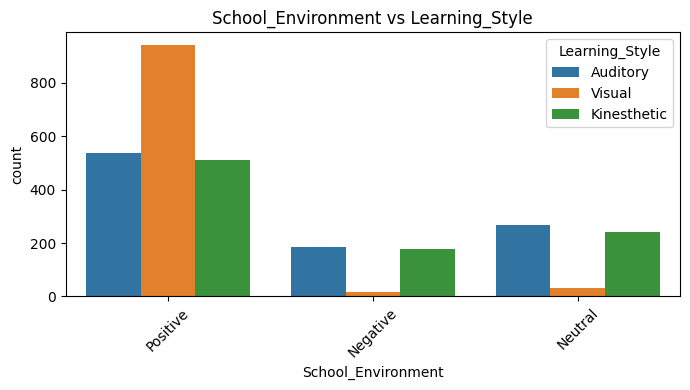

Chi-square test for School_Environment vs Learning_Style → p-value = 0.0000


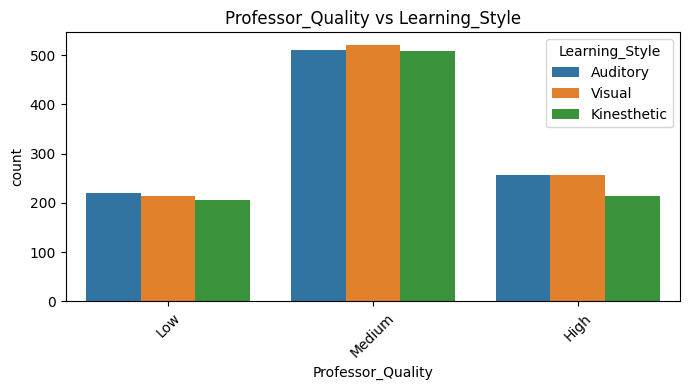

Chi-square test for Professor_Quality vs Learning_Style → p-value = 0.5130


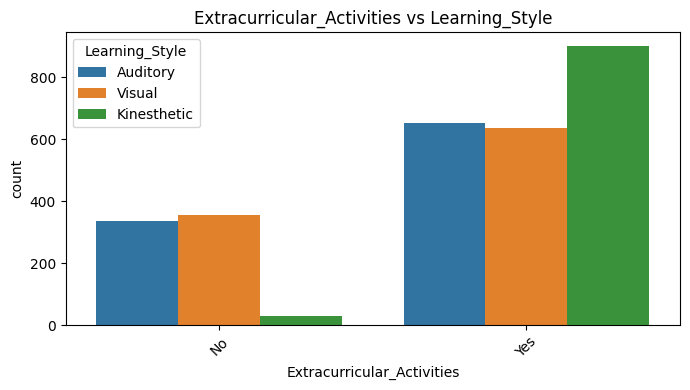

Chi-square test for Extracurricular_Activities vs Learning_Style → p-value = 0.0000


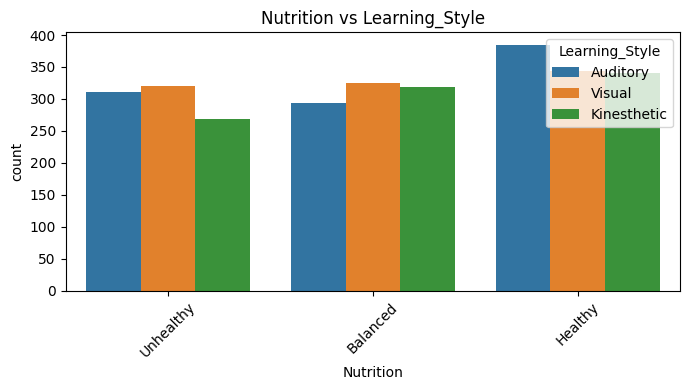

Chi-square test for Nutrition vs Learning_Style → p-value = 0.1047


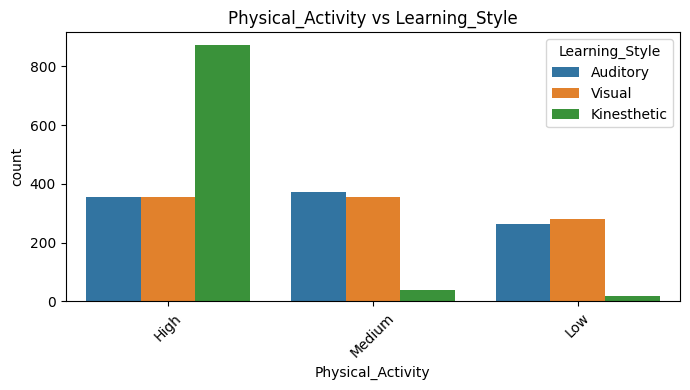

Chi-square test for Physical_Activity vs Learning_Style → p-value = 0.0000


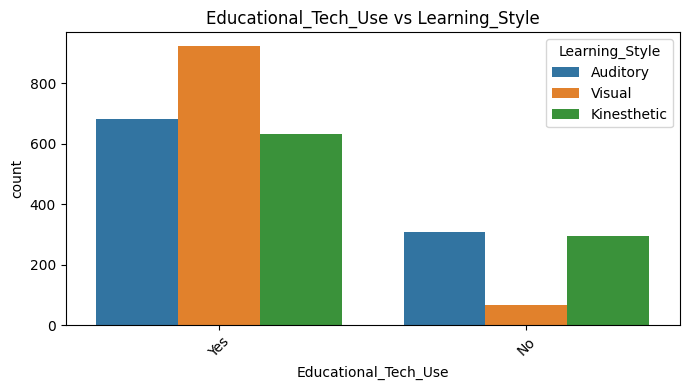

Chi-square test for Educational_Tech_Use vs Learning_Style → p-value = 0.0000


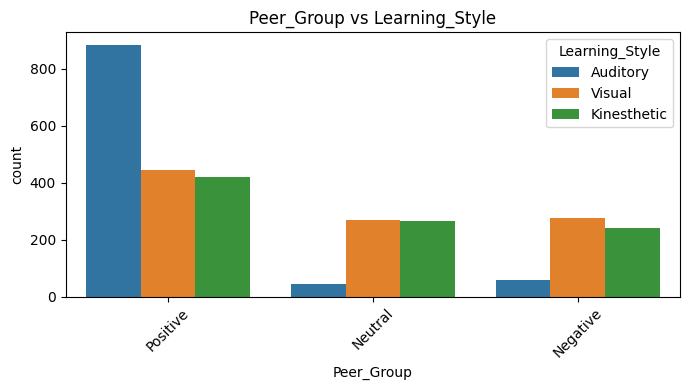

Chi-square test for Peer_Group vs Learning_Style → p-value = 0.0000


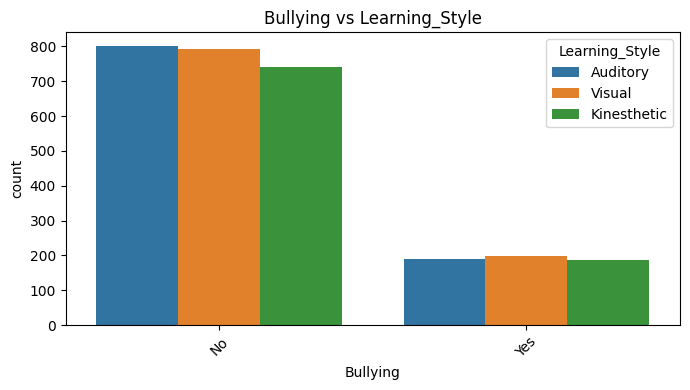

Chi-square test for Bullying vs Learning_Style → p-value = 0.8010


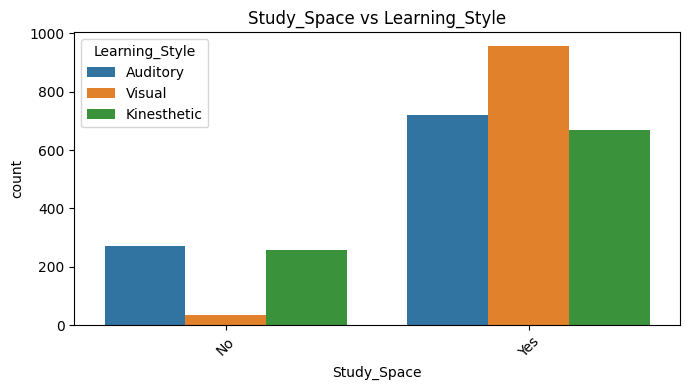

Chi-square test for Study_Space vs Learning_Style → p-value = 0.0000


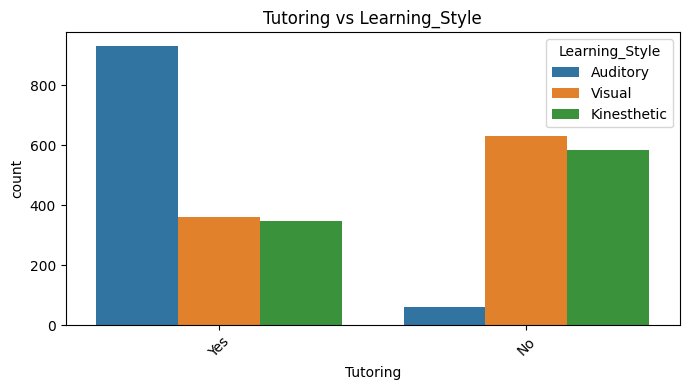

Chi-square test for Tutoring vs Learning_Style → p-value = 0.0000


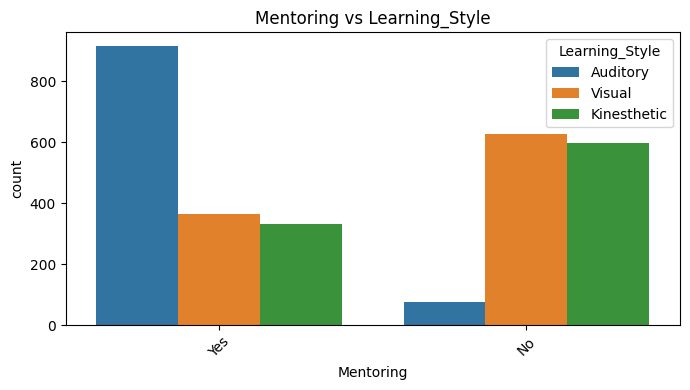

Chi-square test for Mentoring vs Learning_Style → p-value = 0.0000


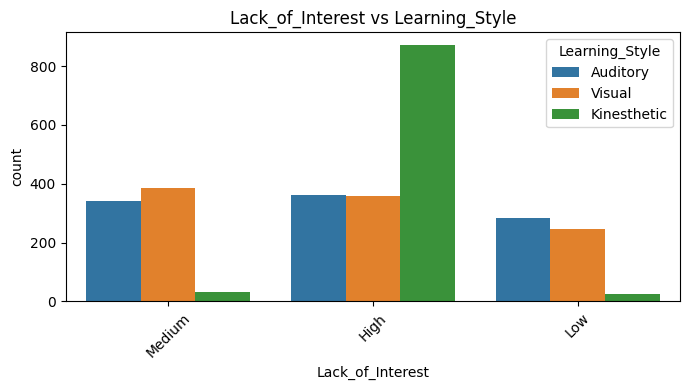

Chi-square test for Lack_of_Interest vs Learning_Style → p-value = 0.0000


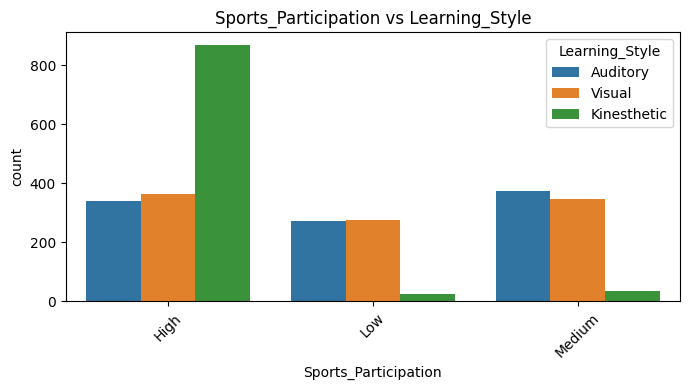

Chi-square test for Sports_Participation vs Learning_Style → p-value = 0.0000


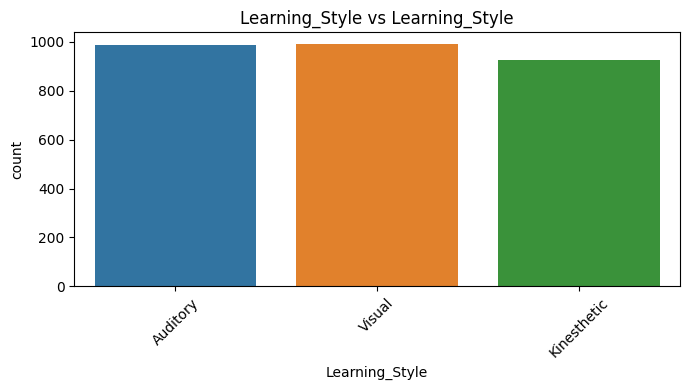

Chi-square test for Learning_Style vs Learning_Style → p-value = 0.0000


In [27]:
import scipy.stats as stats
# Countplots
for col in catgeorical_columns:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Learning_Style', data=df)
    plt.title(f'{col} vs Learning_Style')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    contingency = pd.crosstab(df[col], df['Learning_Style'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    print(f'Chi-square test for {col} vs Learning_Style → p-value = {p:.4f}')

Gender, Family_Income, Major, Parental_Education, Professor_Quality, School_Type, etc.

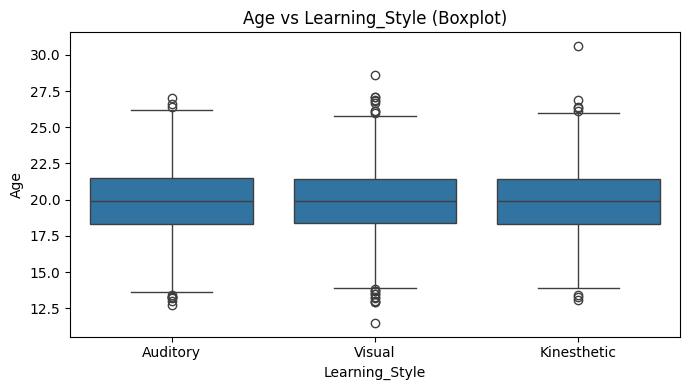

ANOVA for Age vs Learning_Style → p-value = 0.9152
Kruskal-Wallis for Age vs Learning_Style → p-value = 0.8909


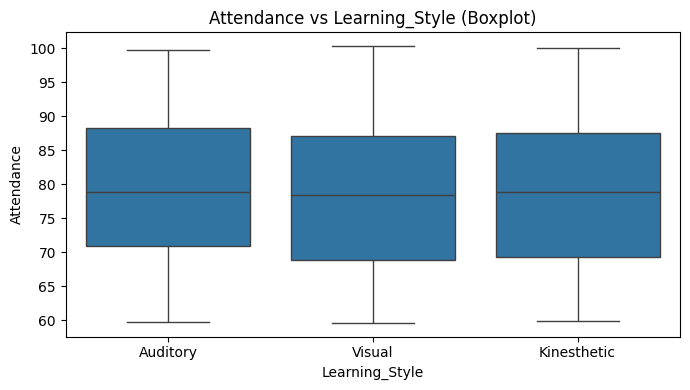

ANOVA for Attendance vs Learning_Style → p-value = 0.0088
Kruskal-Wallis for Attendance vs Learning_Style → p-value = 0.0077


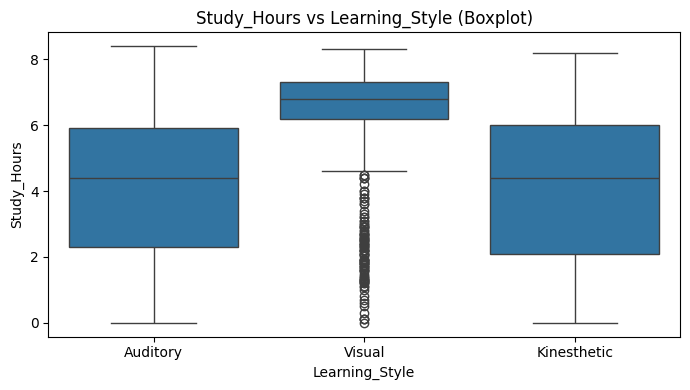

ANOVA for Study_Hours vs Learning_Style → p-value = 0.0000
Kruskal-Wallis for Study_Hours vs Learning_Style → p-value = 0.0000


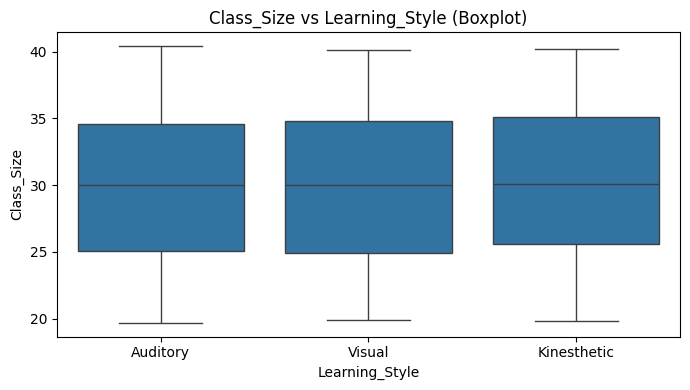

ANOVA for Class_Size vs Learning_Style → p-value = 0.1610
Kruskal-Wallis for Class_Size vs Learning_Style → p-value = 0.1497


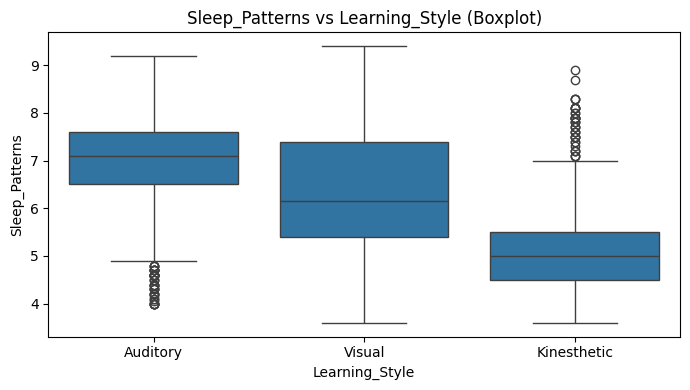

ANOVA for Sleep_Patterns vs Learning_Style → p-value = 0.0000
Kruskal-Wallis for Sleep_Patterns vs Learning_Style → p-value = 0.0000


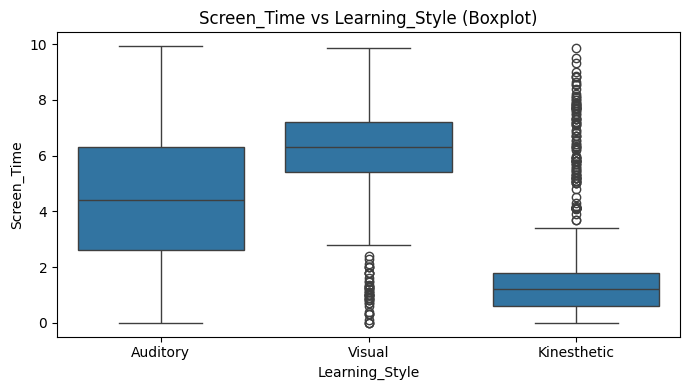

ANOVA for Screen_Time vs Learning_Style → p-value = 0.0000
Kruskal-Wallis for Screen_Time vs Learning_Style → p-value = 0.0000


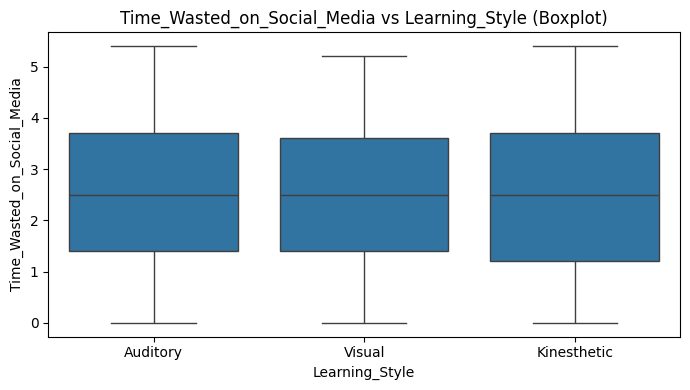

ANOVA for Time_Wasted_on_Social_Media vs Learning_Style → p-value = 0.6971
Kruskal-Wallis for Time_Wasted_on_Social_Media vs Learning_Style → p-value = 0.7157


In [28]:
numerical_cols = ['Age', 'Attendance', 'Study_Hours', 'Class_Size',
                  'Sleep_Patterns', 'Screen_Time', 'Time_Wasted_on_Social_Media']

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Learning_Style', y=col, data=df)
    plt.title(f'{col} vs Learning_Style (Boxplot)')
    plt.tight_layout()
    plt.show()

    # ANOVA Test
    groups = [df[df['Learning_Style'] == style][col] for style in df['Learning_Style'].unique()]
    f_stat, p_anova = stats.f_oneway(*groups)
    print(f'ANOVA for {col} vs Learning_Style → p-value = {p_anova:.4f}')

    # Kruskal-Wallis Test
    h_stat, p_kw = stats.kruskal(*groups)
    print(f'Kruskal-Wallis for {col} vs Learning_Style → p-value = {p_kw:.4f}')


**MULTIVARIATE ANALYSIS**

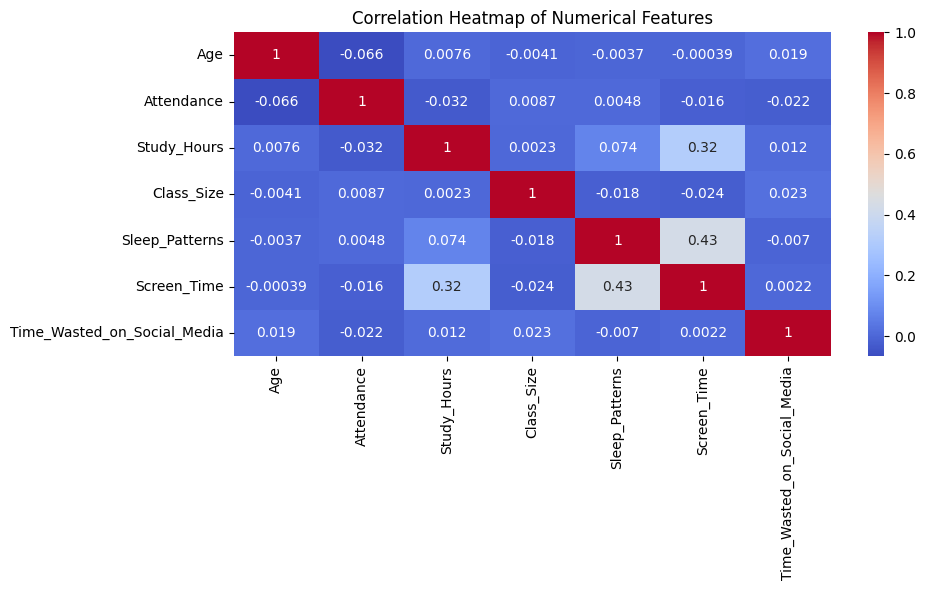

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


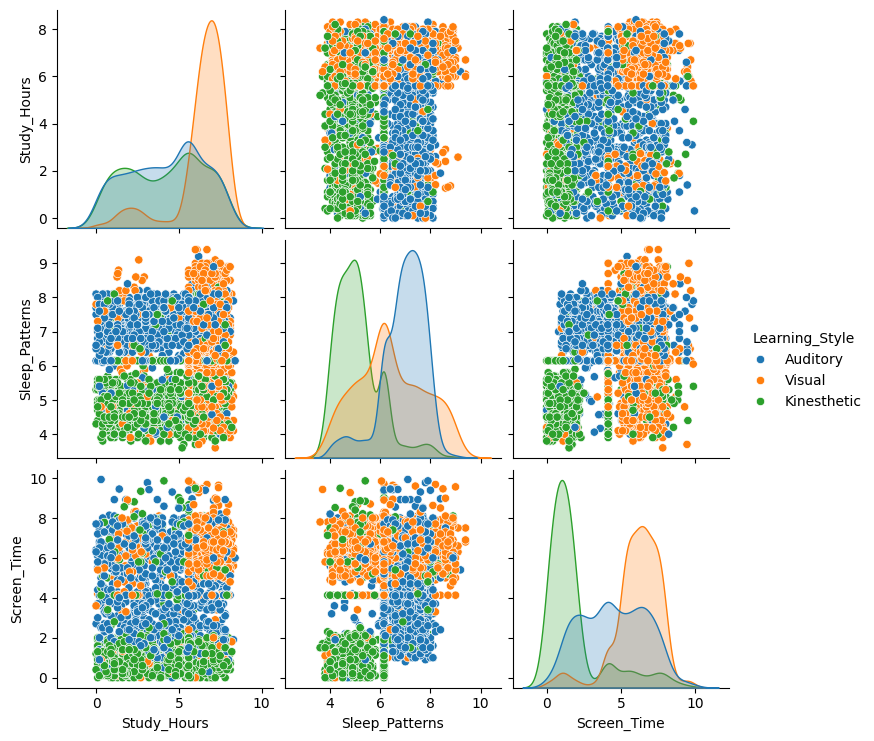

In [30]:
sns.pairplot(df, hue='Learning_Style', vars=['Study_Hours', 'Sleep_Patterns', 'Screen_Time'])


### Pairplot Analysis: Study Hours, Sleep Patterns, and Screen Time vs Learning Style

The pairplot visualizes how three numerical features — **Study Hours**, **Sleep Patterns**, and **Screen Time** — relate to different **Learning Styles** (Auditory, Visual, Kinesthetic).



#### Correlation Insights:

- Mild inverse trend between **Screen Time and Sleep Patterns** for visual learners — higher screen time tends to be associated with slightly lower sleep.
- **Study Hours** and **Sleep Patterns** do not show a strong linear relationship but help segment learners clearly when viewed along with screen time.


#### Implication for Modeling:
These three features show **visible separation** across learning styles, justifying their inclusion in predictive modeling. The patterns suggest:
- **Visual learners** are more screen-and-study driven,
- **Kinesthetic learners** thrive with action and rest,
- **Auditory learners** adopt a more balanced approach.

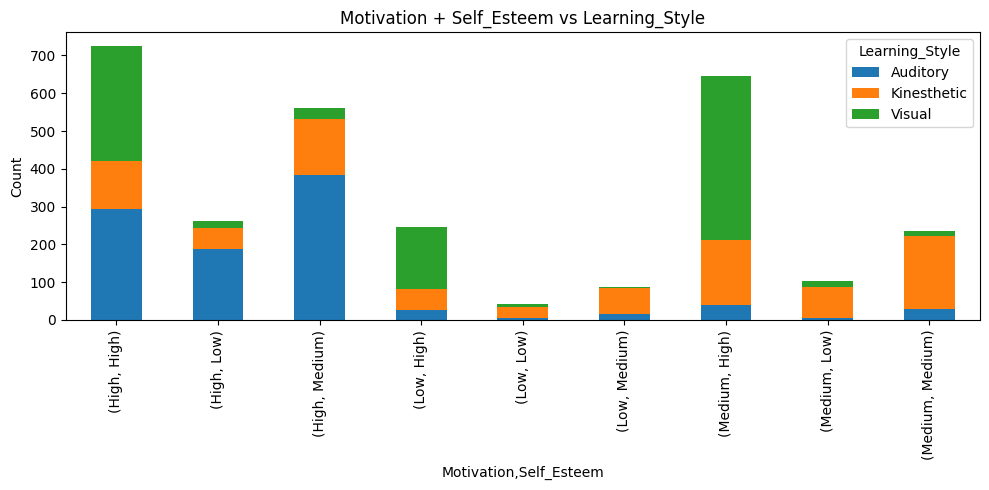

In [31]:
# Example: Motivation + Self_Esteem vs Learning_Style
grouped = df.groupby(['Motivation', 'Self_Esteem', 'Learning_Style']).size().unstack().fillna(0)
grouped.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Motivation + Self_Esteem vs Learning_Style')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


###  Motivation + Self_Esteem vs Learning_Style

This grouped bar chart visualizes how combinations of **Motivation** and **Self_Esteem** levels influence the distribution of **Learning Styles** among students.

####  Key Observations:
- **(High, High)** combo (both high motivation and self-esteem) shows the **highest count**, especially in:
  - **Auditory** and **Visual** learners, indicating this group thrives across multiple styles.
- **(High, Medium)** and **(High, Low)** groups are **dominated by Auditory** learners, suggesting even with lower self-esteem, high motivation sustains auditory preference.
- **(Medium, High)** clearly leans toward **Visual** learners, hinting that moderate motivation with strong self-belief may support visual learning.
- **(Low, High)** sees a surprising surge in **Visual** learners despite low motivation—confidence might override drive.
- **Low motivation** combined with **low or medium self-esteem** has the **lowest counts overall**, with minor representation in **Kinesthetic** learning, indicating low engagement or adaptability.
- **(Medium, Medium)** features a notable cluster of **Kinesthetic** learners, implying that average motivation and self-esteem may foster experiential learning.

####  Insight:
Different learning styles emerge prominently under specific psychological states. This pattern justifies feature interaction in modeling — particularly **Motivation × Self_Esteem** as a combined predictor of preferred **Learning Style**.


# FEATURE SELECTION


- Applied **Chi-square test** for categorical variables.
- Applied **ANOVA and Kruskal-Wallis tests** for numerical variables.
- Features with **p-value < 0.05** were considered statistically significant and retained.
- Insignificant features (p ≥ 0.05) were dropped unless supported by domain knowledge.

In [32]:
# study hours
# class participation
# educational_tech_use
# peer group
# sports_participation
# sleep_patterns
# and motivation

In [33]:
anova_kruskal_remove = ['Age', 'Attendance', 'Class_Size', 'Time_Wasted_on_Social_Media']  # p > 0.7 or borderline

chi_square_remove = ['Gender', 'Parental_Education', 'Family_Income', 'Previous_Grades', 'Major',
                     'School_Type', 'Financial_Status', 'Educational_Resources', 'Stress_Levels',
                     'Professor_Quality', 'Nutrition', 'Bullying']

domain_remove = ['Age', 'Gender', 'Parental_Education', 'Family_Income', 'Previous_Grades', 'Major',
                 'School_Type', 'Financial_Status', 'Attendance', 'Class_Size', 'Bullying',
                 'Nutrition', 'Professor_Quality', 'Stress_Levels', 'Parental_Involvement',
                 'Self_Esteem', 'School_Environment', 'Extracurricular_Activities',
                 'Study_Space', 'Tutoring', 'Mentoring']
# Combine all columns to remove into one set to avoid duplicates
columns_to_remove = set(anova_kruskal_remove + chi_square_remove + domain_remove)

# Drop from df in-place
df.drop(columns=columns_to_remove, inplace=True)

**SPLITING FEATURES AND TARGET**

In [34]:
#establishing features and target

X = df.drop(columns=['Learning_Style'])
y = df['Learning_Style']


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **FEATURE ENCODING**

In [36]:
# 1. One-Hot Encode Categorical Columns in X
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# One-hot encode train and test sets separately, then align columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

# Align columns (very important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [38]:
# Get mapping
print(dict(zip(le.transform(le.classes_), le.classes_)))

{np.int64(0): 'Auditory', np.int64(1): 'Kinesthetic', np.int64(2): 'Visual'}


# **FEATURE SCALING**

In [39]:
from sklearn.preprocessing import StandardScaler
# 2. Standard Scale Numerical Columns
numerical_cols = ['Study_Hours', 'Sleep_Patterns', 'Screen_Time']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# **MODEL EVALUATION**


 Model: Logistic Regression
Accuracy: 0.7869415807560137
Precision (macro): 0.7872909698996656
Recall (macro): 0.7885304659498208
F1 Score (macro): 0.7870645798904766

Classification Report:
               precision    recall  f1-score   support

    Auditory       0.78      0.71      0.74       198
 Kinesthetic       0.83      0.87      0.85       186
      Visual       0.76      0.79      0.78       198

    accuracy                           0.79       582
   macro avg       0.79      0.79      0.79       582
weighted avg       0.79      0.79      0.79       582



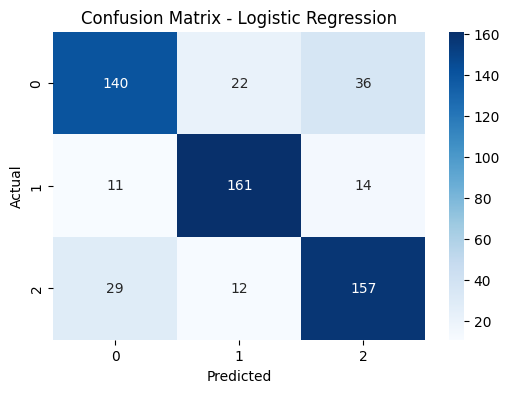


 Model: Random Forest
Accuracy: 0.8281786941580757
Precision (macro): 0.8287709580392507
Recall (macro): 0.8291517323775387
F1 Score (macro): 0.8282425141548438

Classification Report:
               precision    recall  f1-score   support

    Auditory       0.84      0.77      0.81       198
 Kinesthetic       0.84      0.88      0.86       186
      Visual       0.81      0.84      0.82       198

    accuracy                           0.83       582
   macro avg       0.83      0.83      0.83       582
weighted avg       0.83      0.83      0.83       582



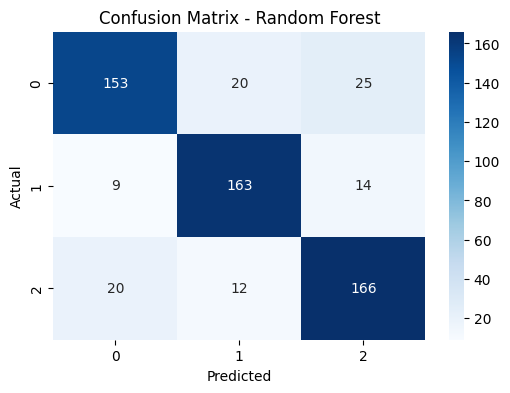


 Model: SVM
Accuracy: 0.8178694158075601
Precision (macro): 0.8184977694781616
Recall (macro): 0.8187248832410123
F1 Score (macro): 0.8183897052206667

Classification Report:
               precision    recall  f1-score   support

    Auditory       0.81      0.78      0.80       198
 Kinesthetic       0.85      0.86      0.85       186
      Visual       0.79      0.82      0.81       198

    accuracy                           0.82       582
   macro avg       0.82      0.82      0.82       582
weighted avg       0.82      0.82      0.82       582



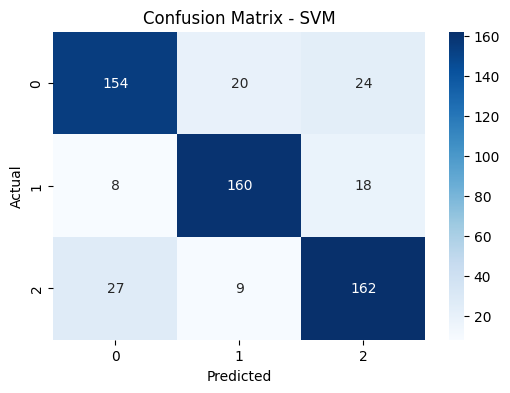

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Define your models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),

}

# Loop to train and evaluate each model
for name, model in models.items():
    print(f"\n Model: {name}")
    model.fit(X_train[numerical_cols], y_train)
    y_pred = model.predict(X_test[numerical_cols])

    # For ROC AUC: Get class probabilities if available
    try:
        y_proba = model.predict_proba(X_test)
    except:
        y_proba = None

    # Basic Metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
    print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
    print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



 Classification Report:
              precision    recall  f1-score   support

    Auditory       0.87      0.85      0.86       198
 Kinesthetic       0.87      0.89      0.88       186
      Visual       0.86      0.86      0.86       198

    accuracy                           0.87       582
   macro avg       0.87      0.87      0.87       582
weighted avg       0.87      0.87      0.87       582



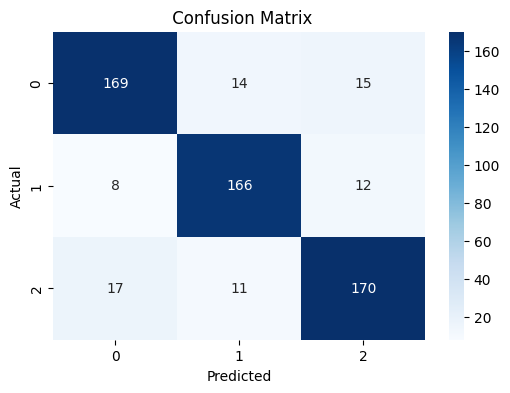

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Encode target (y)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Step 2: Initialize XGBoost with multiclass settings
xgb_model = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Step 3: Fit the model
xgb_model.fit(X_train, y_train_enc)

# Step 4: Predict class labels and probabilities
y_pred_enc = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)  # shape = [n_samples, n_classes]

# Step 5: Decode predictions to original labels
y_pred = le.inverse_transform(y_pred_enc)
y_test_labels = le.inverse_transform(y_test_enc)

# Step 6: Classification Report
print(" Classification Report:")
print(classification_report(y_test_labels, y_pred))

# Step 7: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_labels, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(" Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




# **MODEL SELECTION**

SELECTED MODEL IS XG BOOST WITH HIGHEST ACCURACY

In [ ]:
from sklearn.model_selection import GridSearchCV
# Parameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Grid Search CV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train_enc)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Final model
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best CV Accuracy: 0.8658064516129033

Classification Report:
               precision    recall  f1-score   support

    Auditory       0.90      0.87      0.89       198
 Kinesthetic       0.88      0.91      0.90       186
      Visual       0.90      0.89      0.90       198

    accuracy                           0.89       582
   macro avg       0.89      0.89      0.89       582
weighted avg       0.89      0.89      0.89       582

